In [1]:
import os
import random
from PIL import Image

# Configuration
image_folder = 'Images'
trans_folder = 'Transcriptions'
output_images = 'output_pages'
output_labels = 'output_coordinates'
lines_per_page = 15
total_images_to_process = 15000

# Create output directories
os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

# Get sorted list of images and slice for the first 100
all_segments = sorted([f for f in os.listdir(image_folder) if f.endswith('.jpg')])
all_segments = all_segments[:total_images_to_process]

for i in range(0, len(all_segments), lines_per_page):
    current_chunk = all_segments[i : i + lines_per_page]
    page_index = i // lines_per_page
    
    loaded_data = []
    max_w = 0
    total_h = 0
    
    # 1. Load images and matching transcriptions
    for seg_name in current_chunk:
        # Image
        img_path = os.path.join(image_folder, seg_name)
        img = Image.open(img_path)
        
        # Transcription
        txt_name = seg_name.replace('.jpg', '.txt')
        txt_path = os.path.join(trans_folder, txt_name)
        
        transcription = ""
        if os.path.exists(txt_path):
            with open(txt_path, 'r', encoding='utf-8') as f:
                transcription = f.read().strip()
        else:
            transcription = "[MISSING]"
            
        loaded_data.append((img, transcription))
        max_w = max(max_w, img.width)
        total_h += img.height

    # Canvas Setup
    canvas_w = max_w + 150 
    canvas_h = total_h + (lines_per_page * 60) 
    page_img = Image.new('RGB', (canvas_w, canvas_h), (255, 255, 255))
    
    coord_file_path = os.path.join(output_labels, f"page_{page_index}.txt")
    current_y = random.randint(30, 60) 
    
    with open(coord_file_path, "w", encoding='utf-8') as f:
        for img, text in loaded_data:
            # Randomized placement
            offset_x = random.randint(20, 80)
            gap_y = random.randint(10, 30)
            
            current_y += gap_y
            
            # Coordinates
            x_min, y_min = offset_x, current_y
            x_max, y_max = offset_x + img.width, current_y + img.height
            
            # Paste onto page
            page_img.paste(img, (x_min, y_min))
            
            # New Save format:
            # <|ref|>text<|/ref|><|det|>[[x_min,y_min,x_max,y_max]]<|/det|>
            # actual text
            f.write(f"<|ref|>text<|/ref|><|det|>[ [{x_min},{y_min},{x_max},{y_max}] ]<|/det|>\n")
            f.write(f"{text}\n\n")  # Text followed by an empty line
            
            current_y = y_max

    # Save final page image
    final_page = page_img.crop((0, 0, canvas_w, current_y + 50))
    final_page.save(os.path.join(output_images, f"page_{page_index}.jpg"))

print(f"Done! Created {int(total_images_to_process/lines_per_page)} pages and coordinate files with transcriptions.")

Done! Created 1000 pages and coordinate files with transcriptions.


NameError: name 'page_to_show' is not defined

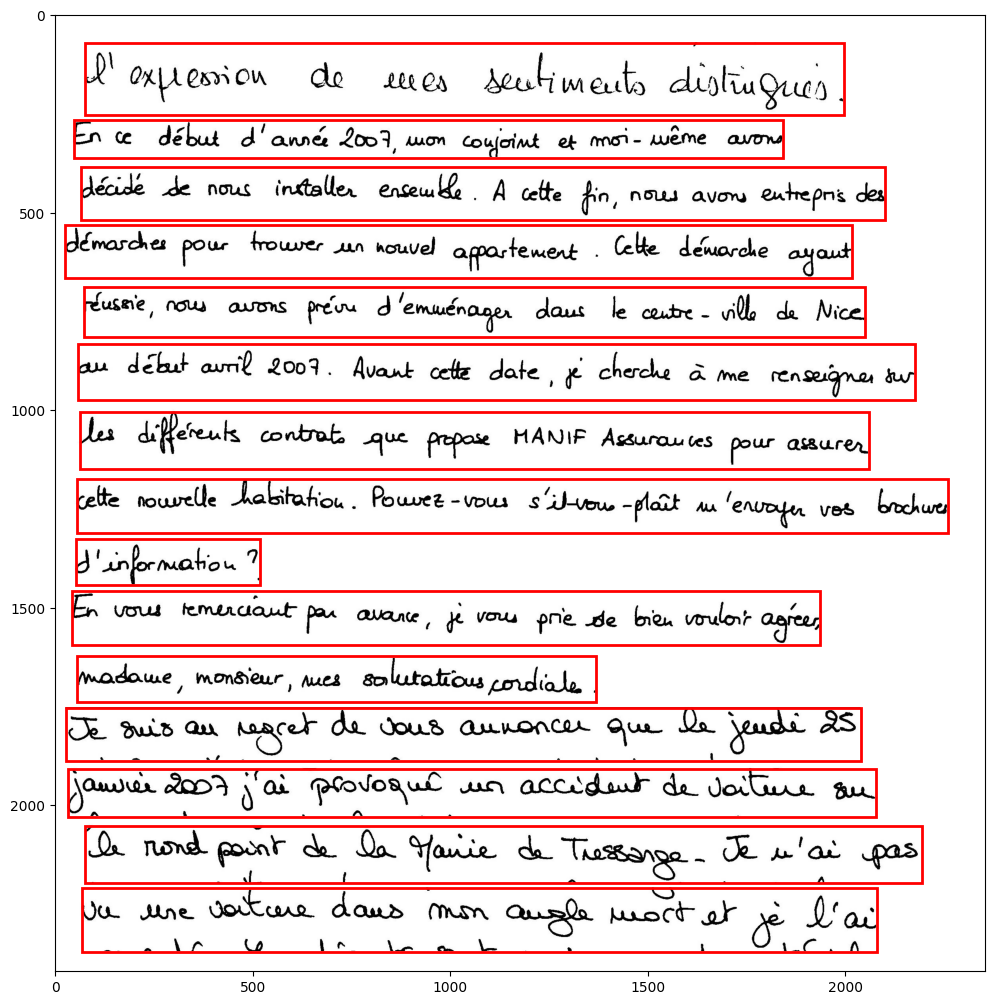

: 

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Paths
image_path = 'output_pages/page_499.jpg'
label_path = 'output_coordinates/page_499.txt'

if os.path.exists(image_path) and os.path.exists(label_path):
    # Load the synthetic page
    img = Image.open(image_path)
    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(img)

    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            # Extract numbers using regex: finds all digits within the coordinate brackets
            # Format expected: [(x_min,y_min),(x_max,y_max)]
            coords_part = line.split('\t')[0]
            nums = re.findall(r'\d+', coords_part)
            
            if len(nums) == 4:
                x_min, y_min, x_max, y_max = map(int, nums)
                
                # Calculate width and height for the rectangle patch
                width = x_max - x_min
                height = y_max - y_min
                
                # Create a Red Rectangle patch
                rect = patches.Rectangle(
                    (x_min, y_min), width, height, 
                    linewidth=2, edgecolor='r', facecolor='none'
                )
                
                # Add the patch to the Axes
                ax.add_patch(rect)

    plt.title(f"Visualizing Segments for {page_to_show}", fontsize=15)
    plt.axis('off')
    plt.show()
else:
    print("Files not found. Please ensure you ran the previous generation script first!")